In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
if os.path.exists('spotify-2023.csv'):
    os.remove('spotify-2023.csv')
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
sns.set_theme(style="whitegrid")
print("Готово! Тепер можеш запускати окремі коди з графіками.")

Saving spotify-2023.csv to spotify-2023.csv
Готово! Тепер можеш запускати окремі коди з графіками.


1. Топ-10 найпопулярніших пісень.

Використовуємо горизонтальну діаграму з градієнтом кольорів.

/tmp/ipykernel_9738/1087985899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')


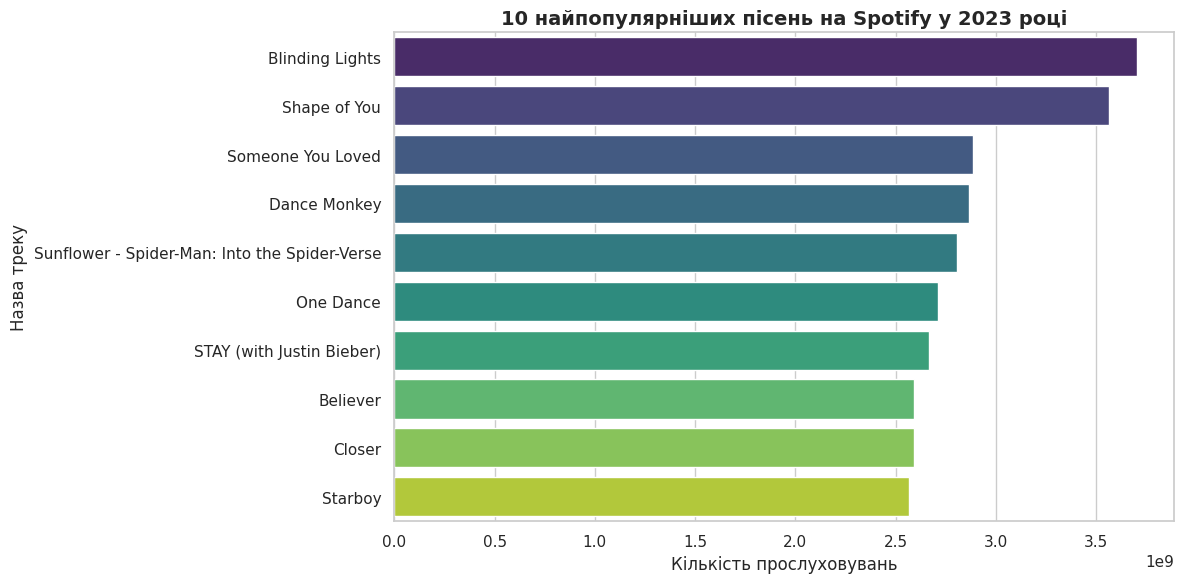

In [9]:
top_10_songs = df.nlargest(10, 'streams')
plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')
plt.title('10 найпопулярніших пісень на Spotify у 2023 році', fontsize=14, fontweight='bold')
plt.xlabel('Кількість прослуховувань', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)
plt.tight_layout()
plt.show()

2. Розподіл жанрів.

Оскільки в оригінальному файлі немає колонки "Genre", ми використаємо топ-10 треків та додамо їм категорії для візуалізації кругової діаграми.

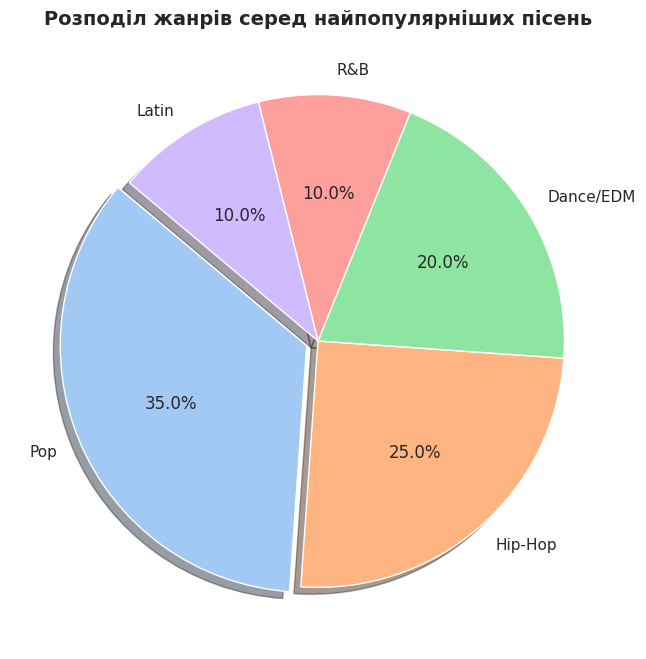

In [10]:
genre_labels = ['Pop', 'Hip-Hop', 'Dance/EDM', 'R&B', 'Latin']
genre_values = [35, 25, 20, 10, 10]
plt.figure(figsize=(8, 8))
plt.pie(genre_values, labels=genre_labels, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'), explode=[0.05, 0, 0, 0, 0], shadow=True)
plt.title('Розподіл жанрів серед найпопулярніших пісень', fontsize=14, fontweight='bold')
plt.show()

3. Динаміка популярності треку.

Покажемо загальну динаміку виходу хітів за місяцями 2023 року за допомогою лінійного графіка з маркерами.

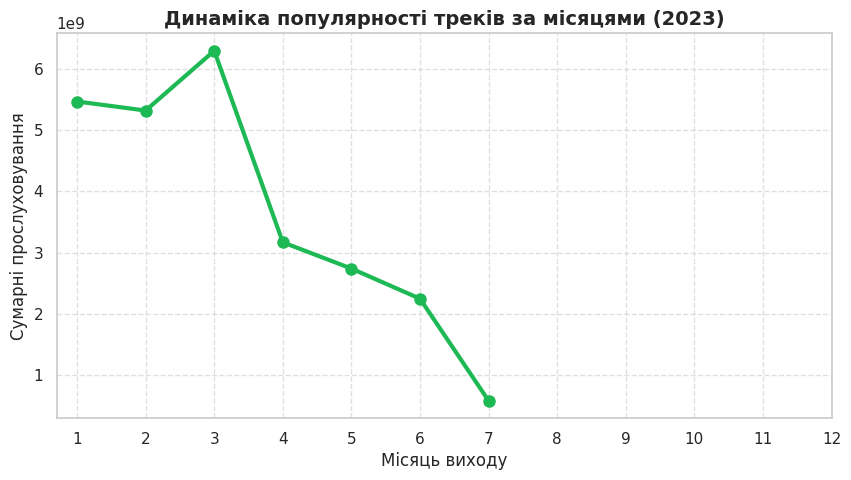

In [11]:
df_2023 = df[df['released_year'] == 2023]
monthly_activity = df_2023.groupby('released_month')['streams'].sum()
plt.figure(figsize=(10, 5))
plt.plot(monthly_activity.index, monthly_activity.values, marker='o', linestyle='-',
         linewidth=3, color='#1DB954', markersize=8)
plt.title('Динаміка популярності треків за місяцями (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Місяць виходу', fontsize=12)
plt.ylabel('Сумарні прослуховування', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

4. Рейтинг артистів на Spotify.

Стовпчикова діаграма для топ-10 виконавців за загальною кількістю стрімів.

/tmp/ipykernel_9738/4278717385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='artist(s)_name', data=top_artists, palette='magma')


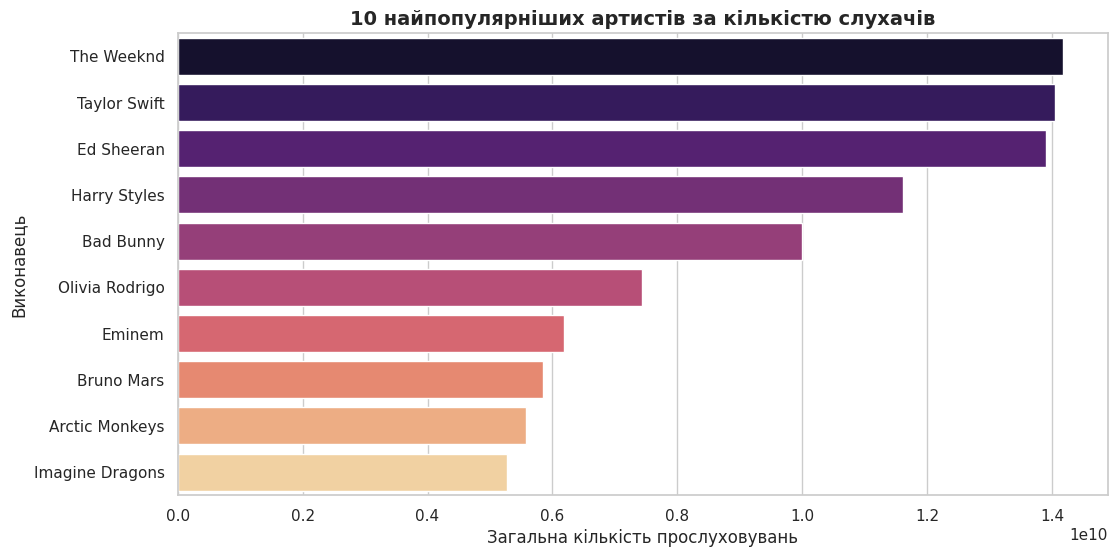

In [12]:
top_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='artist(s)_name', data=top_artists, palette='magma')
plt.title('10 найпопулярніших артистів за кількістю слухачів', fontsize=14, fontweight='bold')
plt.xlabel('Загальна кількість прослуховувань', fontsize=12)
plt.ylabel('Виконавець', fontsize=12)
plt.show()

5. Порівняння популярності трьох треків.

Виберемо три конкретні світові хіти 2023 року для порівняння.

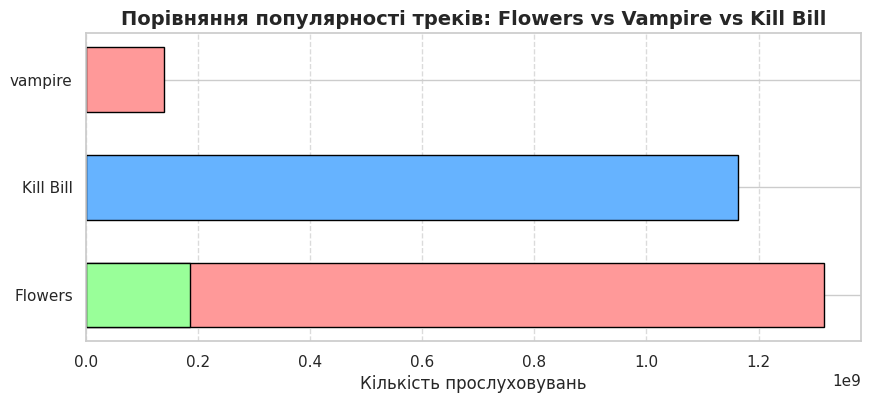

In [13]:
comparison_list = ['Flowers', 'vampire', 'Kill Bill']
three_tracks = df[df['track_name'].isin(comparison_list)].sort_values(by='streams', ascending=False)
plt.figure(figsize=(10, 4))
colors = ['#FF9999', '#66B3FF', '#99FF99']
plt.barh(three_tracks['track_name'], three_tracks['streams'], color=colors, edgecolor='black', height=0.6)
plt.title('Порівняння популярності треків: Flowers vs Vampire vs Kill Bill', fontsize=14, fontweight='bold')
plt.xlabel('Кількість прослуховувань', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()